In [1]:
import pandas as pd

# load processed data
df = pd.read_csv("../data/processed/ems_cleaned.csv", low_memory=False)

# convert datetime columns
date_cols = [
    "INCIDENT_DATETIME",
    "FIRST_ASSIGNMENT_DATETIME",
    "FIRST_ACTIVATION_DATETIME",
    "FIRST_ON_SCENE_DATETIME",
    "INCIDENT_CLOSE_DATETIME",
    "FIRST_TO_HOSP_DATETIME",
    "FIRST_HOSP_ARRIVAL_DATETIME"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [2]:
df.dtypes

CAD_INCIDENT_ID                            int64
INCIDENT_DATETIME                 datetime64[ns]
INITIAL_CALL_TYPE                         object
INITIAL_SEVERITY_LEVEL_CODE                int64
FINAL_CALL_TYPE                           object
FINAL_SEVERITY_LEVEL_CODE                  int64
FIRST_ASSIGNMENT_DATETIME         datetime64[ns]
VALID_DISPATCH_RSPNS_TIME_INDC            object
DISPATCH_RESPONSE_SECONDS_QY             float64
FIRST_ACTIVATION_DATETIME         datetime64[ns]
FIRST_ON_SCENE_DATETIME           datetime64[ns]
VALID_INCIDENT_RSPNS_TIME_INDC            object
INCIDENT_RESPONSE_SECONDS_QY             float64
INCIDENT_TRAVEL_TM_SECONDS_QY            float64
FIRST_TO_HOSP_DATETIME            datetime64[ns]
FIRST_HOSP_ARRIVAL_DATETIME       datetime64[ns]
INCIDENT_CLOSE_DATETIME           datetime64[ns]
HELD_INDICATOR                            object
INCIDENT_DISPOSITION_CODE                 object
BOROUGH                                   object
INCIDENT_DISPATCH_AR

## 1. Exploratory analysis

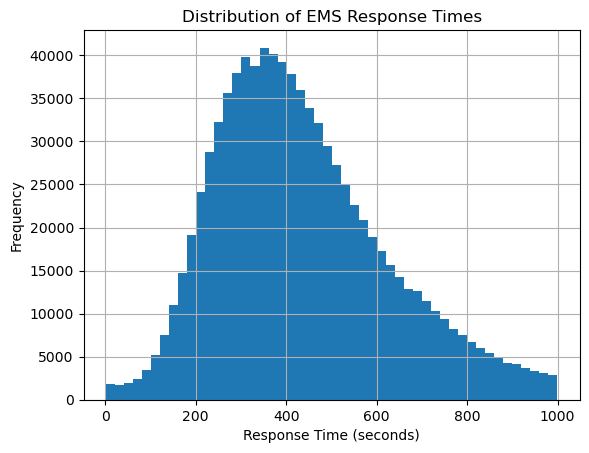

In [3]:
import matplotlib.pyplot as plt

df["INCIDENT_RESPONSE_SECONDS_QY"].hist(bins=50)
plt.xlabel("Response Time (seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of EMS Response Times")
plt.show()

In [4]:
df["INCIDENT_RESPONSE_SECONDS_QY"].describe()

count    874127.000000
mean        434.881721
std         189.176741
min           2.000000
25%         297.000000
50%         406.000000
75%         547.000000
max         999.000000
Name: INCIDENT_RESPONSE_SECONDS_QY, dtype: float64

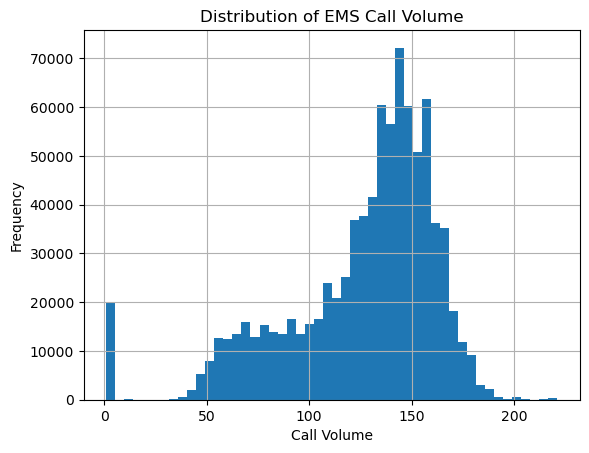

In [5]:
df["call_volume"].hist(bins=50)
plt.xlabel("Call Volume")
plt.ylabel("Frequency")
plt.title("Distribution of EMS Call Volume")
plt.show()

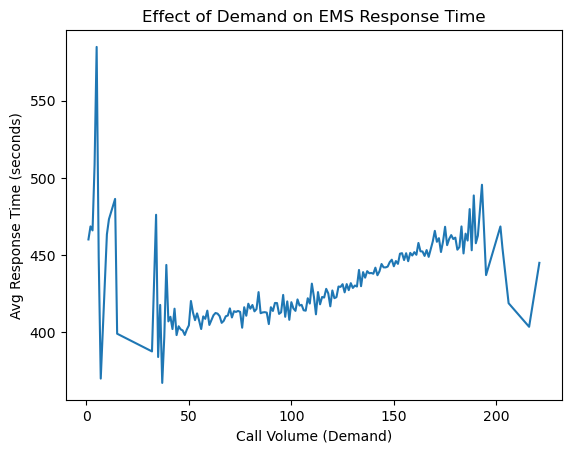

In [6]:
df.groupby("call_volume")["INCIDENT_RESPONSE_SECONDS_QY"].mean().plot()

plt.xlabel("Call Volume (Demand)")
plt.ylabel("Avg Response Time (seconds)")
plt.title("Effect of Demand on EMS Response Time")
plt.show()

C:\Users\Laura Zillmer\AppData\Local\Temp\ipykernel_4652\467627889.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("call_volume_bin")["INCIDENT_RESPONSE_SECONDS_QY"].mean().plot()


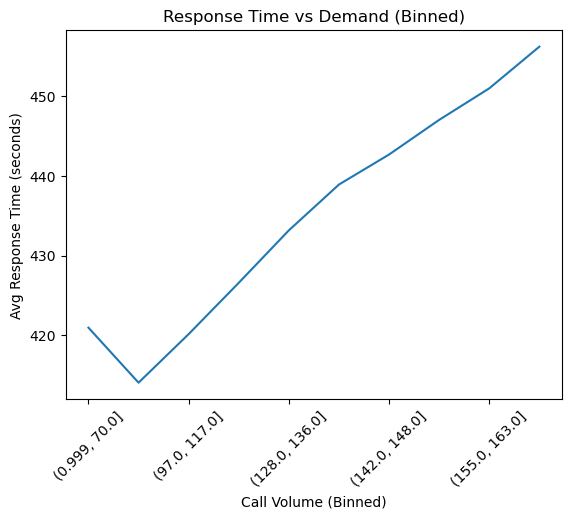

In [7]:
df["call_volume_bin"] = pd.qcut(df["call_volume"], q=10)

df.groupby("call_volume_bin")["INCIDENT_RESPONSE_SECONDS_QY"].mean().plot()

plt.xticks(rotation=45)
plt.xlabel("Call Volume (Binned)")
plt.ylabel("Avg Response Time (seconds)")
plt.title("Response Time vs Demand (Binned)")
plt.show()

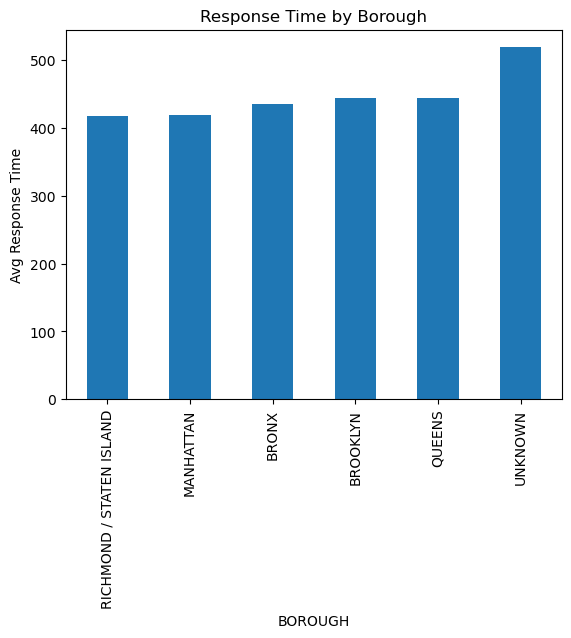

In [8]:
df.groupby("BOROUGH")["INCIDENT_RESPONSE_SECONDS_QY"].mean().sort_values().plot(kind="bar")

plt.ylabel("Avg Response Time")
plt.title("Response Time by Borough")
plt.show()

In [9]:
df["INCIDENT_RESPONSE_SECONDS_QY"].value_counts().head(10)

INCIDENT_RESPONSE_SECONDS_QY
328.0    2128
346.0    2113
336.0    2109
322.0    2107
374.0    2105
343.0    2103
337.0    2100
364.0    2096
356.0    2096
340.0    2094
Name: count, dtype: int64

In [10]:
df["INCIDENT_RESPONSE_SECONDS_QY"].describe()

count    874127.000000
mean        434.881721
std         189.176741
min           2.000000
25%         297.000000
50%         406.000000
75%         547.000000
max         999.000000
Name: INCIDENT_RESPONSE_SECONDS_QY, dtype: float64

## 2. Variable construction

In [12]:
# define high priority
df["high_priority"] = df["INITIAL_SEVERITY_LEVEL_CODE"].isin([1, 2, 3])

# define low priority
df["low_priority"] = df["INITIAL_SEVERITY_LEVEL_CODE"].isin([4, 5, 6, 7, 8])

# low-acuity demand
low_demand = (
    df[df["low_priority"]]
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="low_call_volume")
)

df = df.merge(low_demand, on=["date", "hour"], how="left")

# high-acuity demand
high_demand = (
    df[df["high_priority"]]
    .groupby(["date", "hour"])
    .size()
    .reset_index(name="high_call_volume")
)

df = df.merge(high_demand, on=["date", "hour"], how="left")

df["low_call_volume"] = df["low_call_volume"].fillna(0)
df["high_call_volume"] = df["high_call_volume"].fillna(0)

## 3. Modeling

In [13]:
# filter to high priority dataset
df_high = df[df["high_priority"]].copy()

# create log resposne time
import numpy as np
df_high["log_response_time"] = np.log(df_high["INCIDENT_RESPONSE_SECONDS_QY"])

# define x
import statsmodels.api as sm
X = df_high[["low_call_volume", "high_call_volume", "hour"]]
X = sm.add_constant(X)

#### Model 1 (Baseline)
How total demand affects response time

x: low call volume, high call volume, hour <br>
y: incident response seconds

In [14]:
y1 = df_high["INCIDENT_RESPONSE_SECONDS_QY"]

model1 = sm.OLS(y1, X).fit()
print(model1.summary())

                                 OLS Regression Results                                 
Dep. Variable:     INCIDENT_RESPONSE_SECONDS_QY   R-squared:                       0.001
Model:                                      OLS   Adj. R-squared:                  0.001
Method:                           Least Squares   F-statistic:                     116.7
Date:                          Wed, 25 Mar 2026   Prob (F-statistic):           1.50e-75
Time:                                  14:16:32   Log-Likelihood:            -1.9648e+06
No. Observations:                        300992   AIC:                         3.930e+06
Df Residuals:                            300988   BIC:                         3.930e+06
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

- Each low-accuity call -> response time decreases by .19s
- Each high-acuity call -> response time increases by .6s
- Model explains .1% of variation in response time

#### Model 2 (borough added)
Demand effects controlling for geography

x: low call volume, high call volume, hour, borough <br>
y: incident response seconds

In [25]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

df_high = df[df["high_priority"]].copy()

df_high["low_call_volume"] = df_high["low_call_volume"].fillna(0)
df_high["high_call_volume"] = df_high["high_call_volume"].fillna(0)
df_high["BOROUGH"] = df_high["BOROUGH"].fillna("UNKNOWN")

df_high["log_response_time"] = np.log(df_high["INCIDENT_RESPONSE_SECONDS_QY"])

X = pd.get_dummies(
    df_high[["low_call_volume", "high_call_volume", "hour", "BOROUGH"]],
    drop_first=True
)

X = X.astype(float)
X = sm.add_constant(X)

y1 = df_high["INCIDENT_RESPONSE_SECONDS_QY"].astype(float)

model1_geo = sm.OLS(y1, X).fit()
print(model1_geo.summary())

                                 OLS Regression Results                                 
Dep. Variable:     INCIDENT_RESPONSE_SECONDS_QY   R-squared:                       0.009
Model:                                      OLS   Adj. R-squared:                  0.009
Method:                           Least Squares   F-statistic:                     357.7
Date:                          Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                                  14:33:32   Log-Likelihood:            -1.9636e+06
No. Observations:                        300992   AIC:                         3.927e+06
Df Residuals:                            300983   BIC:                         3.927e+06
Df Model:                                     8                                         
Covariance Type:                      nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------

- Each additional low-acutiy call -> decrease response times by -0.19 seconds
- Each additional high-acuity call -> increase response times by 0.59 seconds
- Fastest response time: Manhattan
- Lowest response time: Queens

#### Model 3 (Interaction model)
Whether low calls slow response when system is busy

x: low call volume, high call volume, interaction = low * high, hour, borough <br>
y: incident response seconds

In [33]:
df_high["interaction"] = (
    df_high["low_call_volume"] * df_high["high_call_volume"]
)

X = pd.get_dummies(
    df_high[["low_call_volume", "high_call_volume", "interaction", "hour", "BOROUGH"]],
    drop_first=True
)

X = X.astype(float)
X = sm.add_constant(X)

y1 = df_high["INCIDENT_RESPONSE_SECONDS_QY"].astype(float)

model_interaction = sm.OLS(y1, X).fit()
print(model_interaction.summary())

                                 OLS Regression Results                                 
Dep. Variable:     INCIDENT_RESPONSE_SECONDS_QY   R-squared:                       0.010
Model:                                      OLS   Adj. R-squared:                  0.010
Method:                           Least Squares   F-statistic:                     340.2
Date:                          Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                                  14:47:28   Log-Likelihood:            -1.9635e+06
No. Observations:                        300992   AIC:                         3.927e+06
Df Residuals:                            300982   BIC:                         3.927e+06
Df Model:                                     9                                         
Covariance Type:                      nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------

- Low-acuity demand only increases response times when high-acuity demand is also high?
- E.g. if high_call_volume = 20, effect = -0.4655 + (0.0092 *20) = -0.2815 <br>
but if high_call_volume = 100, effect = -0.4655 + (0.0092 * 100) = +0.4545 -> each additional low-acuity call increases response by 0.45s

## 4. Simulation